In [7]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random

In [8]:
# Run this once to load the train and test data straight into a dataloader class
# that will provide the batches
batch_size_train = 64
batch_size_test = 1000
train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True)

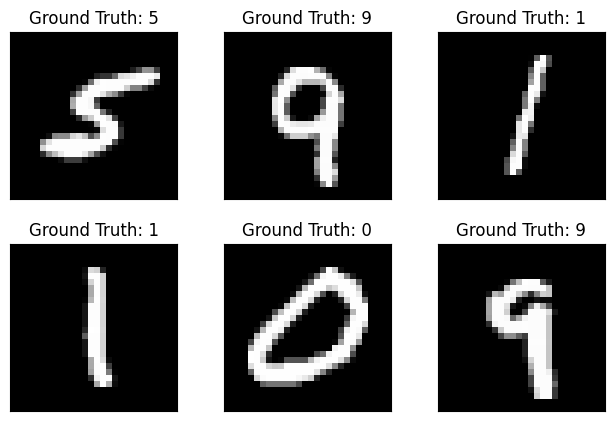

In [9]:
# Let's draw some of the training data
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()

Define the network.  This is a more typical way to define a network than the sequential structure.  We define a class for the network, and define the parameters in the constructor.  Then we use a function called forward to actually run the network.  It's easy to see how you might use residual connections in this format.

In [10]:
from os import X_OK
# TODO Change this class to implement
# 1. A valid convolution with kernel size 5, 1 input channel and 10 output channels
# 2. A max pooling operation over a 2x2 area
# 3. A Relu
# 4. A valid convolution with kernel size 5, 10 input channels and 20 output channels
# 5. A 2D Dropout layer
# 6. A max pooling operation over a 2x2 area
# 7. A relu
# 8. A flattening operation
# 9. A fully connected layer mapping from (whatever dimensions we are at-- find out using .shape) to 50
# 10. A ReLU
# 11. A fully connected layer mapping from 50 to 10 dimensions
# 12. A softmax function.

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 1. Conv1: 1 channel → 10 channels, kernel 5x5
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        # 2+3. MaxPool2d + ReLU (dans forward)
        # 4. Conv2: 10 channels → 20 channels, kernel 5x5
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        # 5. Dropout2D
        self.dropout2d = nn.Dropout2d(p=0.25)
        # 9. Fully Connected:
        #    taille image apres operation = 4x4 (20x4x4=320)
        self.fc1 = nn.Linear(320, 50)  # 320 = 20 * 4 * 4
        # 11. Fully Connected: 50 → 10
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        # x shape: [batch, 1, 28, 28]

        # 1+2+3: Conv + MaxPool + ReLU
        x = self.conv1(x)           # [batch, 10, 24, 24]
        x = F.max_pool2d(x, 2)      # [batch, 10, 12, 12]
        x = F.relu(x)               # [batch, 10, 12, 12]

        # 4+5+6+7: Conv + Dropout + MaxPool + ReLU
        x = self.conv2(x)           # [batch, 20, 8, 8]
        x = self.dropout2d(x)       # Dropout
        x = F.max_pool2d(x, 2)      # [batch, 20, 4, 4]
        x = F.relu(x)               # [batch, 20, 4, 4]

        # 8: Flatten
        x = x.view(-1, 320)         # [batch, 320]

        # 9+10: FC1 + ReLU
        x = F.relu(self.fc1(x))     # [batch, 50]

        # 11+12: FC2 + Softmax
        x = F.log_softmax(self.fc2(x), dim=1)  # [batch, 10]

        return x

In [11]:
# He initialization of weights
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

In [12]:
# Create network
model = Net()
# Initialize model weights
model.apply(weights_init)
# Define optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [13]:
# Main training routine
def train(epoch):
  model.train()
  # Get each
  for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
    # Store results
    if batch_idx % 10 == 0:
      print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(train_loader.dataset), loss.item()))

In [14]:
# Run on test data
def test():
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      output = model(data)
      test_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [15]:
# Get initial performance
test()
# Train for three epochs
n_epochs = 3
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3178: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.7472, Accuracy: 860/10000 (9%)

Train Epoch: 1 [0/60000]	Loss: 2.963303
Train Epoch: 1 [640/60000]	Loss: 2.098582
Train Epoch: 1 [1280/60000]	Loss: 1.774186
Train Epoch: 1 [1920/60000]	Loss: 1.559114
Train Epoch: 1 [2560/60000]	Loss: 1.423671
Train Epoch: 1 [3200/60000]	Loss: 1.102213
Train Epoch: 1 [3840/60000]	Loss: 0.891055
Train Epoch: 1 [4480/60000]	Loss: 0.868406
Train Epoch: 1 [5120/60000]	Loss: 0.811897
Train Epoch: 1 [5760/60000]	Loss: 0.484506
Train Epoch: 1 [6400/60000]	Loss: 0.664502
Train Epoch: 1 [7040/60000]	Loss: 0.758197
Train Epoch: 1 [7680/60000]	Loss: 0.700374
Train Epoch: 1 [8320/60000]	Loss: 0.532837
Train Epoch: 1 [8960/60000]	Loss: 0.432253
Train Epoch: 1 [9600/60000]	Loss: 0.474911
Train Epoch: 1 [10240/60000]	Loss: 0.616715
Train Epoch: 1 [10880/60000]	Loss: 0.402237
Train Epoch: 1 [11520/60000]	Loss: 0.304669
Train Epoch: 1 [12160/60000]	Loss: 0.252938
Train Epoch: 1 [12800/60000]	Loss: 0.476244
Train Epoch: 1 [13440/60000]	Loss: 0.314

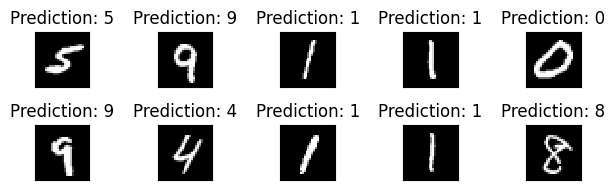

In [16]:
# Run network on data we got before and show predictions
output = model(example_data)

fig = plt.figure()
for i in range(10):
  plt.subplot(5,5,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
plt.show()